# Machine Learning Project | Customer Churn Prediction

In [338]:
# Import libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, classification_report, recall_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [339]:
import sklearn
print(sklearn.__version__)

1.8.0


In [340]:
df = pd.read_csv("data/customer_churn_clean.csv")
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [341]:
df.shape

(7032, 20)

In [342]:
df.describe().T

# TotalCharges → can be very large >> Use Standard Scaler which is less sensitive to outliers.

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
monthly_charges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
total_charges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


## Feature Selection

Encode Categorical variables

In [343]:
# Features
X = df.drop(columns=["churn"])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Ensure numeric
X = X.apply(pd.to_numeric, errors="raise")
X

,senior_citizen,tenure,monthly_charges,total_charges,gender_Male,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_No phone service,multiple_lines_Yes,...,streaming_t_v_No internet service,streaming_t_v_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7028,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7029,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7030,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [344]:
# Feature selection
# total_charges≈tenure×monthly_charges >> drop "total_charges" and keep "tenure", "monthly_charges"
features = [
    "tenure",
    "monthly_charges",
    "contract_One year",
    "contract_Two year",
    "paperless_billing_Yes",
    "payment_method_Electronic check",
    "online_security_Yes",
    "tech_support_Yes",
    "dependents_Yes",
    "partner_Yes",
    "senior_citizen",
    "streaming_movies_Yes",
    "streaming_t_v_Yes",
    "multiple_lines_Yes"
]

In [345]:
X = X[features]

In [346]:
# Target
y = df["churn"].map({"Yes": 1, "No": 0})

Split the data into Train and Test

In [347]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [348]:
# Build correlation dataset
df_corr = X.copy()
df_corr["churn"] = y

# Compute correlation
corr = np.abs(df_corr.corr())

Check Correlation between Features and Target

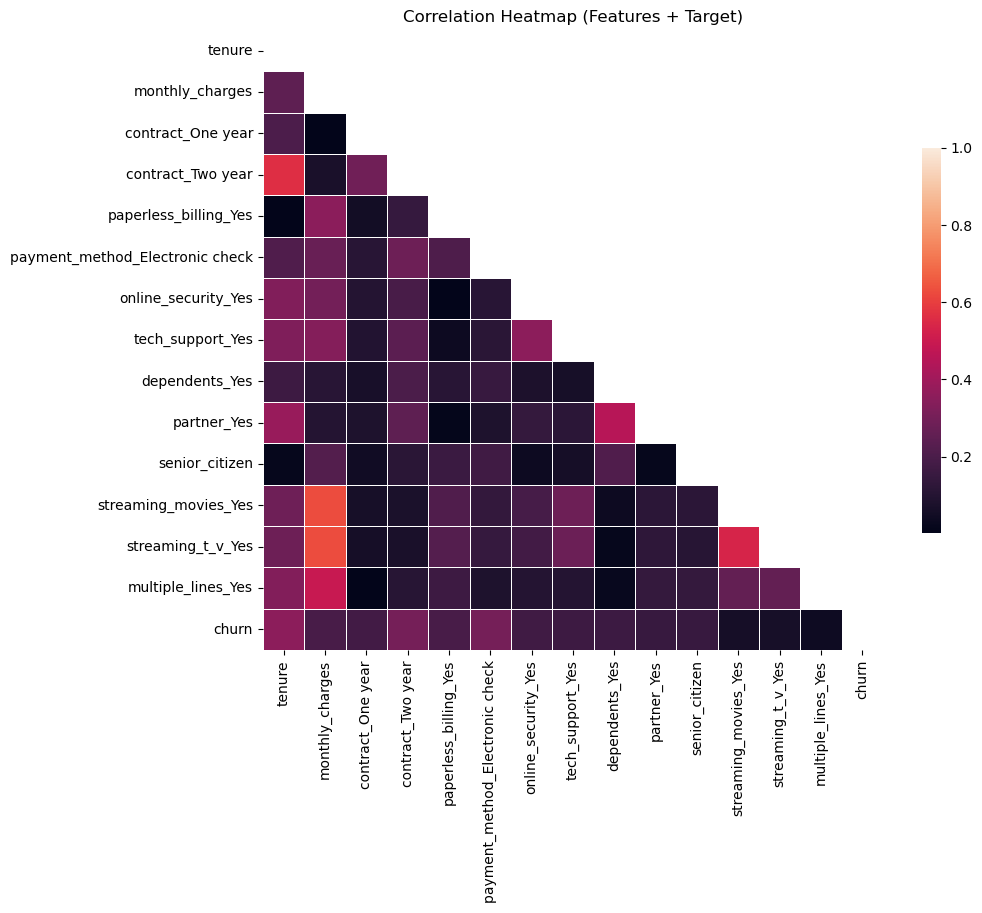

In [349]:
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10,10))

sns.heatmap(
    corr,
    mask=mask,
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=False
)

plt.title("Correlation Heatmap (Features + Target)")
plt.show()

In [350]:
corr_target = df_corr.corr()["churn"].sort_values(ascending=False)
print(corr_target)

churn                              1.000000
payment_method_Electronic check    0.301455
monthly_charges                    0.192858
paperless_billing_Yes              0.191454
senior_citizen                     0.150541
streaming_t_v_Yes                  0.063254
streaming_movies_Yes               0.060860
multiple_lines_Yes                 0.040033
partner_Yes                       -0.149982
dependents_Yes                    -0.163128
tech_support_Yes                  -0.164716
online_security_Yes               -0.171270
contract_One year                 -0.178225
contract_Two year                 -0.301552
tenure                            -0.354049
Name: churn, dtype: float64


Data Scaling

In [351]:
# 1. Import the scaler >> a tool that standardizes the data.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Evaluation metric
💡 Churn is costly:
- Missing a churner = lost revenue ❌

👉 So we want to minimize false negatives

Recall answers: “Of all customers who actually churned, how many did we successfully detect?”

- TP (True Positives) = correctly identified churners ✔
- FN (False Negatives) = missed churners ❌ (VERY expensive for you)

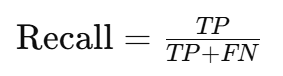

# ML Models

In [352]:
datasets = [
    {"name": "raw", "X_train": X_train, "X_test": X_test},
    {"name": "scaled", "X_train": X_train_scaled, "X_test": X_test_scaled}
]

In [353]:
datasets = [
    {
        "name": "raw",
        "X_train": X_train,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled
    }
]

In [354]:
models = [

    {"name": "LogisticRegression", "model": LogisticRegression(max_iter=1000)},

    {"name": "DecisionTree", "model": DecisionTreeClassifier(max_depth=5, random_state=42)},

    {"name": "RandomForest",
     "model": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)},

    {"name": "XGBoost", "model": XGBClassifier(
         n_estimators=100,
         max_depth=6,
         learning_rate=0.1,
         random_state=42
     )},

    {"name": "VotingClassifier", "model": VotingClassifier(

    estimators=[
        ("Tree", DecisionTreeClassifier(
            max_depth=5, 
            random_state=42
        )),

        ("XGB", XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        )),

        ("LR", LogisticRegression(
            max_iter=1000
        ))
    ],

    voting="soft"
)}
 ]

In [355]:
results = []

for ds in datasets:
    for m in models:

        model = m["model"]
        model_name = m["name"]

        # choose correct data
        if model_name == "LogisticRegression":
            X_train_use = X_train_scaled
            X_test_use = X_test_scaled
        else:
            X_train_use = X_train
            X_test_use = X_test

        model.fit(X_train_use, y_train)
        pred = model.predict(X_test_use)

        results.append({
            "dataset": ds["name"],
            "model": model_name,
            "Recall": recall_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "F1": f1_score(y_test, pred),
            "Accuracy": accuracy_score(y_test, pred)
        })

        print(f"{ds['name']:>10} | {model_name:<20} done")

results_df = pd.DataFrame(results).sort_values(
    "Recall", ascending=False
).reset_index(drop=True)

results_df        

       raw | LogisticRegression   done
       raw | DecisionTree         done
       raw | RandomForest         done
       raw | XGBoost              done
       raw | VotingClassifier     done


,dataset,model,Recall,Precision,F1,Accuracy
0,raw,DecisionTree,0.596257,0.564557,0.579974,0.770434
1,raw,LogisticRegression,0.500000,0.603226,0.546784,0.779673
2,raw,VotingClassifier,0.497326,0.661922,0.567939,0.798863
3,raw,RandomForest,0.494652,0.600649,0.542522,0.778252
4,raw,XGBoost,0.494652,0.618729,0.549777,0.784648


# Hyperparameter tuning

**Random Search** - we define probability distributions for each hyperparameter, from which random values are sampled.

In [356]:
# Parameter grid per model
grid = {
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"]
    },

    "DecisionTree": {
        "max_depth": [3, 5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },

    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10]
    },


    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2]
    },

    "VotingClassifier": {
        "voting": ["soft", "hard"],
        "weights": [[1,1,1], [2,1,1], [2,2,1]],
        "Tree__max_depth": [3,5,10],
        "XGB__n_estimators": [100,200],"XGB__max_depth": [3,4,6],
        "XGB__learning_rate": [0.05,0.1],
        "LR__C": [0.1,1,10]
        }
}

In [357]:
# Model list
models = {

    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "VotingClassifier": VotingClassifier(
        estimators=[
            ("Tree", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),

            ("XGB", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=4,
                random_state=42,
                eval_metric="logloss"
            )),

            ("LR", LogisticRegression(
                max_iter=1000
            ))
        ],

        voting="soft"
    )

}

In [358]:
# Run Random Search for all models
results = []

for name, model in models.items():

    print(f"Running Random Search for {name}")

    # Use scaled data only for Logistic Regression
    if name == "LogisticRegression":
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled

    else:
        X_train_use = X_train
        X_test_use = X_test

    # Random Search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid[name],
        n_iter=10,
        cv=5,
        scoring="recall",
        random_state=42,
        n_jobs=-1
    )

    # Fit
    random_search.fit(X_train_use, y_train)

    # Best model
    best_model = random_search.best_estimator_

    # Predict
    y_pred = best_model.predict(X_test_use)

    # Metrics
    recall = recall_score(y_test, y_pred)

    # Store results
    results.append({

        "model": name,
        "best_params": random_search.best_params_,
        "Recall": recall,
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

    print(f"{name} done ✔ | Recall: {recall:.4f}")

Running Random Search for LogisticRegression


c:\Users\glint\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\glint\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LogisticRegression done ✔ | Recall: 0.5000
Running Random Search for DecisionTree
DecisionTree done ✔ | Recall: 0.5348
Running Random Search for RandomForest
RandomForest done ✔ | Recall: 0.5053
Running Random Search for XGBoost
XGBoost done ✔ | Recall: 0.4733
Running Random Search for VotingClassifier
VotingClassifier done ✔ | Recall: 0.5000


In [359]:
# Results table
results_df = pd.DataFrame(results).sort_values("Recall", ascending=False)
results_df

,model,best_params,Recall,Precision,F1,Accuracy
1,DecisionTree,"{'min_samples_split': 5, 'min_samples_leaf': 5...",0.534759,0.534759,0.534759,0.752665
2,RandomForest,"{'n_estimators': 50, 'min_samples_split': 5, '...",0.505348,0.619672,0.556701,0.786070
0,LogisticRegression,"{'penalty': 'l2', 'C': 10}",0.500000,0.603226,0.546784,0.779673
4,VotingClassifier,"{'weights': [2, 1, 1], 'voting': 'soft', 'XGB_...",0.500000,0.573620,0.534286,0.768301
3,XGBoost,"{'n_estimators': 100, 'max_depth': 5, 'learnin...",0.473262,0.625442,0.538813,0.784648


**Grid Search** - we define a grid of hyperparameter values we want to try. Grid Search tries all possible combinations.

In [360]:
# Apply Grid Search
results = []

for name, model in models.items():

    print(f"Running Grid Search for {name}")

    # -------------------------
    # SELECT DATA PROPERLY
    # -------------------------
    if name == "LogisticRegression":
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test

    # -------------------------
    # GRID SEARCH
    # -------------------------
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid[name],
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    grid_search.fit(X_train_use, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_use)

    recall = recall_score(y_test, y_pred)

    results.append({
        "model": name,
        "best_params": grid_search.best_params_,
        "Recall": recall,
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

    print(f"{name} done ✔ | Recall: {recall:.4f}")

Running Grid Search for LogisticRegression


c:\Users\glint\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LogisticRegression done ✔ | Recall: 0.5000
Running Grid Search for DecisionTree
DecisionTree done ✔ | Recall: 0.5615
Running Grid Search for RandomForest
RandomForest done ✔ | Recall: 0.4599
Running Grid Search for XGBoost
XGBoost done ✔ | Recall: 0.4840
Running Grid Search for VotingClassifier
VotingClassifier done ✔ | Recall: 0.5000


In [362]:
# Results table
results_df = pd.DataFrame(results).sort_values("Recall", ascending=False)
results_df

,model,best_params,Recall,Precision,F1,Accuracy
1,DecisionTree,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.561497,0.549738,0.555556,0.761194
0,LogisticRegression,"{'C': 10, 'penalty': 'l2'}",0.500000,0.603226,0.546784,0.779673
4,VotingClassifier,"{'LR__C': 0.1, 'Tree__max_depth': 10, 'XGB__le...",0.500000,0.573620,0.534286,0.768301
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.483957,0.651079,0.555215,0.793888
2,RandomForest,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.459893,0.644195,0.536661,0.788913
